In [101]:
# | output: false
# | code-fold: true
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import percentileofscore
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

This notebook serves as a handover guide for understanding and interacting with the project's key processes, which enrich and analyse UKRI-funded research publication data. The notebook is divided into sections corresponding to key steps in the pipeline:

![](handover_notebook_files/dsit_proj3_diagram.svg){width=80% fig-align="center"}

### Sections:
1. **Data Collection and Enrichment**:
   - Reverse DOI lookups and OpenAlex matching.
   - Improving metadata coverage for publications from Gateway to Research (GtR).
2. **Citation Intent and PDF Content Parsing**:
   - Extracting citation intents using Semantic Scholar data, and parse PDFs.
   - Understanding the relationship between citation contexts and research impact.
3. **Diversity and Collaboration Metrics**:
   - Exploring the interdisciplinary nature of research teams.
   - Using diversity metrics to evaluate team composition and its association with research outcomes.

---

## 0. Preliminary steps

### 0.1. Setting up the Kedro environment

Before exploring these processes, we’ll ensure the Kedro environment is loaded and ready for interaction.

In [1]:
# | output: false

# Load Kedro extensions
%load_ext kedro.ipython

# Reload the Kedro context
%reload_kedro

[12/19/24 19:29:34] INFO     Using                                                                  ]8;id=742261;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=967481;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/ked                
                             ro/framework/project/rich_logging.yml' as logging configuration.                      

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=808532;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=720071;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#61\61]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=691494;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=900452;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Resolved project path as: /home/dampudia/projects/dsit-impact.         ]8;id=301675;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=35846;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#178\178]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[12/19/24 19:29:34] WARNING  /home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedr ]8;id=641402;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=621207;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/warnings.py#110\110]8;;\
                             o_viz/__init__.py:13: KedroVizPythonVersionWarning: Please be advised                 
                             that Kedro Viz is not yet fully                                                       
                                     compatible with the Python version you are currently using.                   
                               warnings.warn(                                                                      
                                                                                                                   

...

                    INFO     Registered line magic 'run_viz'                                        ]8;id=55152;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=657768;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#151\151]8;;\

                    INFO     Resolved project path as: /home/dampudia/projects/dsit-impact.         ]8;id=539385;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=115095;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#178\178]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

                    INFO     Kedro project dsit-impact                                              ]8;id=666623;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=702136;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#144\144]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=37684;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=629649;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#145\145]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=166442;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=989170;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/ipython/__init__.py#151\151]8;;\

---

### 0.2. Exploring and interacting with the data catalog

Kedro’s Data Catalog is the central hub for managing project datasets. In this section, we’ll list a handful of available datasets, inspect their metadata, and load a sample dataset to get started.

You can always refer to `conf/base/catalog.yml` to find more about each of the elements in the catalog, including the file path, and database credentials.

#### 0.2.1 Listing available datasets

In [2]:
# List all datasets available in the catalog
catalog.list()[:5]


[
    'gtr.data_collection.publications.raw',
    'gtr.data_collection.publications.intermediate',
    'oa.data_matching.gtr.doi.raw',
    'oa.data_matching.gtr.doi.intermediate',
    'cr.data_matching.gtr.doi.raw'
]

#### 0.2.2 Loading and previewing a dataset

The primary method for loading datasets in Kedro is via `catalog.load()`. However, Kedro pipelines do not require users to explicitly load datasets. Instead, transformation operations are defined in `nodes` (self-contained functions), and the `pipeline` automatically fetches and loads the required elements from the catalog, matching the argument names in the `nodes`.

In [3]:
# | output: false

# Load the GtR publications dataset
gtr_data = catalog.load("oa.publications.gtr.map.primary")

                    INFO     Loading data from oa.publications.gtr.map.primary                  ]8;id=845764;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=29195;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (ParquetDataset)...                                                                   

This repository supports various approaches to storing data, with Parquet files being the most commonly used format. For instance, the `gtr_data` object we just loaded is stored as a Parquet file.

In [4]:
# Display the first few rows
gtr_data.head()

,outcome_id,id,doi
0,1A455359-E3E1-4BD0-83A8-F45ADEB1616F,W2104199131,10.18637/jss.v045.i05
1,0326D8C4-7E7F-4EA3-8956-BC238BA159D6,W2955962623,10.1002/sia.6681
2,036EE6D9-9151-4587-8E6C-8B90B27CC0A7,W4300594366,10.1073/pnas.2206885119
3,1ADB6934-CA45-49B3-896B-6EF0F2463CC3,W2947461406,10.48550/arxiv.1902.10486
4,1AF3DF51-985B-4236-B4FD-1969847FE8B2,W2772579088,10.1590/1516-3180.2017.0174100917


Additionally, the project uses [partitioned Parquet datasets](https://docs.kedro.org/projects/kedro-datasets/en/kedro-datasets-6.0.0/api/kedro_datasets.partitions.PartitionedDataset.html), which enable operations to be broken down into manageable chunks. Partitioned datasets are stored as dictionaries, where:
- **Keys** correspond to chunk IDs (often combining a slice ID and a timestamp).
- **Values** reference individual Parquet files for each chunk.

In [5]:
# | output: false

# Load the partitioned raw GtR object
gtr_data_ptd = catalog.load("gtr.data_collection.publications.raw")

[12/19/24 18:47:15] INFO     Loading data from gtr.data_collection.publications.raw             ]8;id=275690;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=197995;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (PartitionedDataset)...                                                               

In [6]:
# Display the first key, value pair
first_key = list(gtr_data_ptd.keys())[0]
first_value = gtr_data_ptd[first_key]()
print(f"Key: {first_key}")
first_value.head(2)

Key: p1


,project_id,outcome_id,pubMedId,isbn,issn,doi,title,chapterTitle,type,publication_date,journal_title,publication_url,author
0,3450502B-5849-4606-BD71-9D432B26FD2E,1A455359-E3E1-4BD0-83A8-F45ADEB1616F,None,None,None,http://dx.doi.org/10.18637/jss.v045.i05,REALCOM-IMPUTE Software for Multilevel Multipl...,None,Journal Article/Review,2011-01-01,Journal of Statistical Software,http://www.jstatsoft.org/v45/i05/paper,Carpenter J
1,DB63DCA3-276E-4568-82CF-A8F5CCA7A7BA,1A75C325-F519-4926-8548-63081CFE63BD,None,None,None,None,Weather shocks and nutritional status of disad...,None,Working Paper,2013-01-01,None,http://www.york.ac.uk/media/economics/document...,"Edoka, I.P."




Note that the partitioned datasets are lazily saved and loaded. This has many advantages, allowing for efficient use of memory resources. It however requires instantiating the loader function of each of the lazy partitiones, as in `gtr_data_ptd[first_key]()`. In spite of this, this structure facilitates efficient processing and storage for large-scale data.

## 1. Data Collection and enrichment

This section focuses on adding publication metadata to Gateway to Research (GtR) outputs through iterative DOI lookups using OpenAlex and CrossRef. We progressively increase DOI coverage through:

1. An initial matching with OpenAlex for existing DOIs.
2. Reverse lookups using OpenAlex and CrossRef APIs to identify missing DOIs.
3. A second round of matching with OpenAlex to finalise the dataset.

![](handover_notebook_files/section1.svg){width=40% fig-align="center"}

The relevant pipelines are `data_collection_gtr` and `data_collection_oa`.

---

### 1.1 Fetching GtR Data

The Gateway to Research (GtR) dataset provides metadata for publications supported by UKRI funding. However, many records lack DOIs, making it difficult to link these publications to external citation databases.

Let’s begin by fetching the initial GtR dataset and examining its coverage.


In [7]:
# | output: false
# Load the GtR dataset
gtr_data = catalog.load("gtr.data_collection.publications.intermediate")

[12/19/24 18:47:18] INFO     Loading data from gtr.data_collection.publications.intermediate    ]8;id=948977;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=211295;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (ParquetDataset)...                                                                   

In [8]:
gtr_data.shape

(1276892, 13)

As of December 2024, we have collected over 1.2 million project outputs using Gateway to Research's API. This process is implemented in the pipeline available in this repository as `data_collection_gtr`. 

In [ ]:
# Display the first few rows
gtr_data.head(2)

,project_id,outcome_id,pubMedId,isbn,issn,doi,title,chapterTitle,type,publication_date,journal_title,publication_url,author
0,3450502B-5849-4606-BD71-9D432B26FD2E,1A455359-E3E1-4BD0-83A8-F45ADEB1616F,None,None,None,http://dx.doi.org/10.18637/jss.v045.i05,REALCOM-IMPUTE Software for Multilevel Multipl...,None,Journal Article/Review,2011-01-01,Journal of Statistical Software,http://www.jstatsoft.org/v45/i05/paper,Carpenter J
1,DB63DCA3-276E-4568-82CF-A8F5CCA7A7BA,1A75C325-F519-4926-8548-63081CFE63BD,None,None,None,None,Weather shocks and nutritional status of disad...,None,Working Paper,2013-01-01,None,http://www.york.ac.uk/media/economics/document...,"Edoka, I.P."


An important step in our analysis involves leveraging Digital Object Identifiers (DOIs) to map these outputs to key academic variables, such as citation metrics and authorship details. While many outputs in GtR include a DOI, this is not universal, and a portion remains unmapped.

In [ ]:
# | code-fold: true
f"Number of unique DOIs in GtR: {gtr_data.doi.nunique()}"

'Number of unique DOIs in GtR: 603576'

In [11]:
# Calculate initial DOI coverage
gtr_initial_coverage = gtr_data["doi"].notnull().mean() * 100

'Initial DOI Coverage in GtR: 86.41%'

In [ ]:
# | code-fold: true
f"Initial DOI Coverage in GtR: {gtr_initial_coverage:.2f}%"

Additionally, although a majority of outputs report DOIs, these identifiers are often repeated across multiple outputs, typically associated with overlapping projects that share co-authors. Addressing these duplicates helps to improve the dataset's quality and usability for downstream work.

In [30]:
# | code-fold: true
# | output: false
# combining IDs in first pass with the GtR outcome ID
oa_to_gtr_id = catalog.load("oa.publications.gtr.map.primary")
oa_to_gtr_id = oa_to_gtr_id.merge(gtr_data, on="outcome_id")

[12/19/24 18:55:41] INFO     Loading data from oa.publications.gtr.map.primary                  ]8;id=628595;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=21586;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (ParquetDataset)...                                                                   

### 1.2 Initial matching with OpenAlex

The first step uses OpenAlex to match records in the GtR dataset based on existing DOIs. This step establishes a baseline for coverage.

In [13]:
# | output: false
oa_first_match = catalog.load("oa.data_matching.gtr.doi.intermediate")

[12/19/24 18:48:22] INFO     Loading data from oa.data_matching.gtr.doi.intermediate            ]8;id=869003;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=13458;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (ParquetDataset)...                                                                   

In [ ]:
# | code-fold: true
f"Number of unique DOIs in OA: {oa_first_match.doi.nunique()}"

'Number of unique DOIs in OA: 558799'

An initial round of API requests to OpenAlex, using the DOIs available in the Gateway to Research data, yields approximately 560,000 matches. This indicates that nearly all but 40,000 DOIs associated with project outcomes can be directly matched.

In [32]:
# | code-fold: true
oa_first_w_ids = oa_first_match.merge(oa_to_gtr_id[["id", "outcome_id"]], on="id", how="left")
matched_gtr_ids = gtr_data.merge(oa_first_w_ids, on="outcome_id", how="left")

In [33]:
# Calculate match rate based on matched_gtr_ids with non-null id
match_rate = matched_gtr_ids["id"].notnull().mean() * 100

'Match rate based on matched GtR IDs: 83.99%'

In [ ]:
# | code-fold: true
f"Match rate based on matched GtR IDs: {match_rate:.2f}%"

This procedure retrieves metadata from OpenAlex for over 80% of all outcome IDs in the GtR data. New data includes co-authors, publication citations, external identifiers, and relevant topics and concepts, which will be useful in estimating the topic diversity of UKRI-funded research.

In [ ]:
# | code-fold: true
oa_first_match.head(2)

,id,doi,pmid,mag_id,title,publication_date,cited_by_count,counts_by_year,authorships,topics,concepts,grants
0,W2768286292,https://doi.org/10.3847/2041-8213/aa9f0c,None,2768286292,GW170608: Observation of a 19 Solar-mass Binar...,2017-12-18,1129,"[[2024, 58], [2023, 61], [2022, 76], [2021, 12...","[[A5109427038, I122411786, US, first], [A51079...","[[T10463, Pulsars and Gravitational Waves Rese...","[[C48372109, Binary number], [C149792144, Coal...",None
1,W2104199131,https://doi.org/10.18637/jss.v045.i05,None,2104199131,<b>REALCOM-IMPUTE</b>Software for Multilevel M...,2011-01-01,336,"[[2024, 21], [2023, 8], [2022, 3], [2021, 53],...","[[A5072810129, I36234482, GB, first], [A508354...","[[T10243, Statistical Methods and Bayesian Inf...","[[C58041806, Imputation (statistics)], [C52740...",None


### 1.3 Second matching with OpenAlex and CrossRef

After the initial OpenAlex matching, we perform reverse lookups using both OpenAlex and CrossRef APIs to address missing DOIs. These reverse lookups use metadata such as titles, authors, and publication years to identify DOIs for records without them. Finally, we combine these results and perform a second matching round with OpenAlex to enrich the dataset further.

#### Reverse Lookups: OpenAlex and CrossRef

The reverse lookups with OpenAlex and CrossRef follow these key steps:
1. **Metadata-based search**: Both platforms use bibliographic metadata (e.g., title, author, journal, publication year) to identify missing DOIs for unmatched records.
2. **Result filtering and scoring**: Potential matches are filtered and scored for relevance:
   - **OpenAlex**: Matches are retrieved using the `search works` API.
   - **CrossRef**: Matches are scored using fuzzy matching on titles, authors, and journals, combined with a composite scoring system.
3. **Combining results**: Matched DOIs from both OpenAlex and CrossRef are combined in node `select_better_match`.

#### Final OpenAlex matching
After combining the reverse lookup results, we perform a second round of OpenAlex matching to retrieve metadata for records that now have DOIs.

In [16]:
# | output: false
oa_second_match = catalog.load("oa.publications.gtr.primary")

[12/19/24 18:49:17] INFO     Loading data from oa.publications.gtr.primary (ParquetDataset)...  ]8;id=43992;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=726845;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

In [17]:
oa_second_match.shape

(597572, 12)

The second OpenAlex match results in some additional 50,000 OpenAlex papers that match to at least one outcome in the GtR data.

In [34]:
# | code-fold: true
oa_second_w_ids = oa_second_match.merge(oa_to_gtr_id[["id", "outcome_id"]], on="id", how="left")
matched_gtr_ids = gtr_data.merge(oa_second_w_ids, on="outcome_id", how="left")

In [35]:
# Calculate match rate based on matched_gtr_ids with non-null id
match_rate = matched_gtr_ids["id"].notnull().mean() * 100

'Match rate based on matched GtR IDs: 85.45%'

In [ ]:
# | code-fold: true
f"Match rate based on matched GtR IDs: {match_rate:.2f}%"

Unlike the outcomes with DOIs already included in the GtR data, these new matches obtained through reverse lookups only slightly increase the match rate, bringing it to just over 85%.

In [18]:
# | code-fold: true
oa_second_match.head(2)

,id,doi,pmid,mag_id,title,publication_date,cited_by_count,counts_by_year,authorships,topics,concepts,grants
0,W2768286292,https://doi.org/10.3847/2041-8213/aa9f0c,None,2768286292,GW170608: Observation of a 19 Solar-mass Binar...,2017-12-18,1129,"[[2024, 58], [2023, 61], [2022, 76], [2021, 12...","[[A5109427038, I122411786, US, first], [A51079...","[[T10463, Pulsars and Gravitational Waves Rese...","[[C48372109, Binary number], [C149792144, Coal...",None
1,W2104199131,https://doi.org/10.18637/jss.v045.i05,None,2104199131,<b>REALCOM-IMPUTE</b>Software for Multilevel M...,2011-01-01,336,"[[2024, 21], [2023, 8], [2022, 3], [2021, 53],...","[[A5072810129, I36234482, GB, first], [A508354...","[[T10243, Statistical Methods and Bayesian Inf...","[[C58041806, Imputation (statistics)], [C52740...",None


## 2. Citation intent and section identification

The dataset, with its expanded DOI coverage, helps improve coverage of downstream analysis. DOIs now serve as more reliable keys to access external data sources, including detailed citation contexts and full-text documents. 

Building on this foundation, the next steps focus on:
- **Understanding citation contexts** by collecting citation intents and identifying how publications are referenced in scholarly work.
- **Exploring document structure** by parsing PDF sections to determine where citations occur within a publication.

![](handover_notebook_files/section2.svg){width=40% fig-align="center"}

The relevant pipelines are `data_collection_s2` and `data_processing_pdfs`.

### 2.1. Citation Intent and Influence using Semantic Scholar

To better understand the academic influence of UKRI-funded research, we leverage the Semantic Scholar API to collect detailed citation intent and influence metrics. 

#### 2.1.1 Citation Intent Retrieval

The first step uses Semantic Scholar’s API to retrieve citation intents for matched DOIs in the OpenAlex dataset. Citation intents classify the nature of a citation (e.g., background, method, or result) and include additional context. This data provides a deeper understanding of how publications are used in the academic ecosystem.

- **Inputs**: Dataset of matched DOIs from OpenAlex (`oa.publications.gtr.primary`).
- **Outputs**: Partitioned dataset of citation intents (`s2.citation_details.raw`).
- **Intermediate Step**: Concatenates partitioned outputs into a single dataset for analysis (`s2.citation_details.intermediate`).

In [3]:
# | output: false
s2_citations_dict = catalog.load("s2.citation_details.raw")
s2_citations_example = list(s2_citations_dict.values())[0]()

[12/19/24 19:30:24] INFO     Loading data from s2.citation_details.raw (PartitionedDataset)...  ]8;id=262661;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=601508;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

In [7]:
# | code-fold: true
s2_citations_example.sample(5)

,id,pmid,doi,mag_id,is_open_access,pdf_url,influential,intent,context
6865,W4323660938,,10.1103/PhysRevD.107.055029,,True,http://link.aps.org/pdf/10.1103/PhysRevD.107.0...,False,background,"The excluded parameter space is shown in gray,..."
7065,W4389961161,,10.48550/arXiv.2406.03766,,False,None,True,background,"Existing works in the privacy literature, such..."
716,W4210792795,37153606,10.3389/fimmu.2023.1156758,,True,https://www.frontiersin.org/articles/10.3389/f...,False,background,"Likewise, clonal expansion of CD8+ T cells has..."
5489,W4313219621,,10.1007/s42114-023-00737-x,,True,https://www.researchsquare.com/article/rs-3039...,False,methodology,"In this study, the electrocatalysts are succes..."
2682,W4206195597,,10.1007/s12583-023-1859-6,,False,None,True,background,…becomes an emerging research field that could...


Through this matching process, we have identified approximately 3.4 million unique papers citing outputs from GtR for which a positive OpenAlex match was established. Collectively, these papers represent over 15 million citations. 

#### 2.1.2 Paper Metadata Retrieval

In parallel with citation intents, the pipeline also collects paper-level metadata, such as:
- Open access status.
- PDF availability.
- Influential citation counts.

This step provides additional descriptive characteristics of publications, which can be used to identify open access trends and measure publication impact.

- **Inputs**: Dataset of matched DOIs from OpenAlex.
- **Outputs**: Partitioned dataset of paper metadata (`s2.paper_details.raw`).
- **Intermediate Step**: Combines partitioned outputs into a unified dataset (`s2.paper_details.intermediate`).

In [8]:
# | output: false
s2_papers_dict = catalog.load("s2.paper_details.raw")
s2_papers_example = list(s2_papers_dict.values())[0]()

[12/19/24 19:37:44] INFO     Loading data from s2.paper_details.raw (PartitionedDataset)...     ]8;id=39089;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=753983;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

In [39]:
# | code-fold: true
s2_papers_example.sample(5)

,id,influential,is_open_access,pdf_url
6246,W4390833043,0,False,None
433,W4229029495,1,True,https://academic.oup.com/jcem/article-pdf/107/...
368,W4295366905,0,True,None
9277,W4284893833,2,True,https://www.biorxiv.org/content/biorxiv/early/...
2126,W4319720160,0,True,https://academic.oup.com/jrsssc/article-pdf/72...


#### 2.1.3 Combining Data

To efficiently manage large datasets, the pipeline uses oracles in the data catalog to optionally skip Semantic Scholar papers that have already been processed. This mechanism ensures that redundant API calls are avoided, saving time and computational resources.

### 2.2 Parsing PDF Content

With citation intents and metadata collected, this step identifies where citations occur within the 2 million PDFs linked to UKRI-funded research included in the S2 data. The PDF parsing process extracts citation sections and maps them to specific document headings (e.g., "Introduction," "Methods").

PDF processing relies on tools like Grobid and SciPDF to analyse document structure. The parsing step is optimised by checking the data catalog for already-parsed PDFs, ensuring only new records (or unsuccessfuly parsed ones) are processed. 

In [41]:
# | output: false
# Load parsed citation sections
parsed_sections_dict = catalog.load("pdfs.section_details.raw")
parsed_sections_example = list(parsed_sections_dict.values())[0]()

[12/19/24 19:55:44] INFO     Loading data from pdfs.section_details.raw (PartitionedDataset)... ]8;id=206704;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=738420;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

In [43]:
# | code-fold: true
parsed_sections_example.sample(5)

,parent_id,doi,mag_id,pmid,section_index,section_heading,main_section_heading
1504,W2896485194,10.1002/14651858.CD013398.pub3,,33471371,-2,Error,Error
310,W1900802472,10.1002/14651858.CD000371.pub7,2973016055,31508807,132,Agreements and disagreements with other studie...,Empirical Design
536,W2132367212,10.1002/14651858.CD007646.PUB2,2783159663,30970390,5,Main results,Background
615,W2132367212,10.1002/14651858.CD007646.PUB2,2783159663,30970390,135,Comparison 1,Results
1455,W3020992444,10.1002/14651858.CD013207.pub2,,34383961,70,Cochrane Database of Systematic Reviews,Background


More than 900,000 PDFs are succesfully parsed. Unsuccessful attempts are often the result of outdated PDF URLs or journals who throttle access to the scrapers. Although coverage is as a result lower than that of Semantic Scholar data, the results still serve to provide additional nuance as to how UKRI-funded research is used.


## 3. Diversity Metrics from Topics and Team Composition

This section measures the diversity of research topics and team composition within UKRI-funded publications. We calculate diversity metrics such as **Variety**, **Evenness**, and **Disparity** by analysing historical data on topics associated with GtR-affiliated authors and their publications.

![](handover_notebook_files/section3.svg){width=40% fig-align="center"}

The relevant pipelines are `data_processing_authors` and `data_results_team_metrics`. 

### 3.1 Collecting Author and Topic Data

To calculate diversity metrics, the pipeline first collects historical topic data for all GtR-affiliated authors using OpenAlex. The data spans publications dating back to 2007, capturing:
- **Author publication topics**: Retrieved from OpenAlex taxonomies.
- **CWTS taxonomy levels**: Grouped into subfields, fields, and domains to enable hierarchical analysis.

This process uses OpenAlex's API in the same manner as described in Section 1, and collects publication data for over 900,000 unique researchers in the Gateway to Research data. 

In [44]:
# | output: false
# Load author topic data
author_dict = catalog.load("authors.oa_dataset.raw")
author_example = list(author_dict.values())[0]()

[12/19/24 20:37:35] INFO     Loading data from authors.oa_dataset.raw (PartitionedDataset)...   ]8;id=267231;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=433894;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\

In [45]:
# | code-fold: true
author_example.sample(5)

,id,author,publication_date,topics
28813,W4387560257,A5072132945,2023-01-01,"[[T12579, Defect Identification using Positron..."
34114,W4385325762,A5100394072,2023-07-27,"[[T10549, Neonatal Lung Development and Respir..."
25709,W2558091178,A5007170420,2016-06-01,"[[T10590, Chalcogenide Semiconductor Thin Film..."
43696,W1976716413,A5014300283,2012-03-16,"[[T11809, Advanced NMR Techniques and Applicat..."
4509,W2802919254,A5087519538,2017-10-01,"[[T11044, Particle Detector Development and Pe..."


### 3.2 Aggregating Co-Author Topics

To calculate diversity metrics, the pipeline aggregates topics across all co-authors of a publication. This includes:

1. **Historical topic frequencies**:
   - Topics are weighted by their occurrence across an author’s historical publications.
   - Frequencies are aggregated by taxonomy level (e.g., subfields, fields, domains) to capture different levels of topic granularity.

2. **Topic distributions**:
   - For each publication, the co-author topic distributions are combined to create a unified topic profile.
   - These profiles serve as the basis for calculating diversity metrics.

3. **Topic embeddings and distance matrix**:
   - Topics are embedded into a continuous space using the SPECTER pre-trained language model.
   - A distance matrix between the output embeddings quantifies the dissimilarity between topics, providing the foundation for calculating **disparity**.


In [46]:
# | output: false
# Load author topic data
cumulative_domains = catalog.load("authors.domain.cumulative_aggregates.intermediate")

[12/19/24 20:50:05] INFO     Loading data from                                                  ]8;id=72945;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=750151;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             authors.domain.cumulative_aggregates.intermediate                                     
                             (ParquetDataset)...                                                                   

In [ ]:
# | code-fold: true
cumulative_domains.sample(5)

,author,year,publications,total_publications,frequency
2603520,A5078722284,2006,2,17,"[6.207, 2.3, 2.875, 0.2678]"
10078286,A5020035966,2015,4,58,"[7.543, 20.9, 0.35, 3.514]"
3406061,A5032279126,2021,5,52,"[29.31, 0.0, 0.4082, 10.22]"
387151,A5002906837,2017,9,94,"[42.7, 0.583, 39.16, 1.293]"
8802165,A5018697167,2019,5,65,"[2.207, 0.0, 43.25, 0.0]"


### 3.3 Calculating Diversity Metrics

Using the collected topic data, the pipeline computes diversity metrics following the modified **DIV function** proposed by Leydesdorff et al. (2019). These metrics capture three dimensions of diversity:

In [ ]:
# | output: false
# Load author topic data
diversity_results = catalog.load("authors.domain.diversity_components.intermediate")

[12/19/24 20:53:17] INFO     Loading data from authors.domain.diversity_components.intermediate ]8;id=108336;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=12238;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (ParquetDataset)...                                                                   

In [ ]:
# | code-fold: true
diversity_results.sample(5)

,author,year,yearly_publication_count,total_publication_count,variety,evenness,disparity
6526206,A5043863693,2017,1,13,0.50,0.800000,0.719756
4215775,A5007719231,2020,2,8,0.50,0.800000,0.884232
3639654,A5054789767,2006,1,75,0.25,0.000000,0.000000
8426873,A5047538382,2017,2,9,0.50,0.800000,0.884232
8191213,A5058015553,2009,3,76,0.50,0.246154,0.719756



#### 1. Variety

**Variety** represents the breadth of unique disciplines or topics involved in a research paper or team. In the context of team science, high variety suggests contributions from a wide range of fields. 

$$
\text{Variety} = \frac{nc}{N}
$$

where:
- $ nc $: The number of unique disciplines or topics present.
- $ N $: The total possible number of disciplines in the dataset.

This component captures how many distinct fields are involved, with higher values indicating greater diversity of expertise or research themes.

#### 2. Evenness

**Evenness** reflects the balance of contributions from each discipline, highlighting how evenly the topics or disciplinary inputs are distributed across the research. A perfectly balanced paper or team would have equal representation across all fields, while an imbalance indicates that certain disciplines dominate the work. 

$$
\text{Evenness} = 1 - \text{Gini}
$$

where:
- **Gini coefficient**: A statistical measure of distribution inequality, ranging from 0 (perfect balance) to 1 (perfect inequality). By taking $ 1 - \text{Gini} $, we ensure that values closer to 1 indicate a more balanced distribution.

#### 3. Disparity

**Disparity** measures the distinctiveness or **dissimilarity** between disciplines within a research team or paper. This dimension captures the extent to which the included fields differ from one another, as more distinct fields can contribute to a more interdisciplinary output.

$$
\text{Disparity} = \frac{\sum d_{ij}}{nc \times (nc - 1)}
$$

where:
- $ d_{ij} $: The distance or dissimilarity between disciplines $ i $ and $ j $, typically sourced from a disparity matrix that quantifies the “distance” between different fields.
- $ nc $: The number of unique disciplines represented in the research.

The metrics are computed for both individual publications and co-author teams. The latter


In [51]:
# | output: false
# Load author topic data
gtr_diversity_results = catalog.load("publications.domain.coauthor_diversity_scores.intermediate")

[12/19/24 20:55:03] INFO     Loading data from                                                  ]8;id=403122;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=219457;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             publications.domain.coauthor_diversity_scores.intermediate                            
                             (ParquetDataset)...                                                                   

In [52]:
# | code-fold: true
gtr_diversity_results.sample(5)

,id,variety,evenness,disparity
50223,W1999950116,0.75,0.006348,0.733001
26860,W1966765126,1.00,0.401693,0.834283
113756,W2091197170,1.00,0.783854,0.834283
223537,W2559793677,1.00,0.068359,0.834283
174879,W2201224967,1.00,0.075521,0.834283


## 4. Master Dataset Generation

The final step in the pipeline integrates data from various sources to produce a master dataset. This dataset provides a comprehensive view of UKRI-funded research, incorporating metadata, citation contexts, PDF section details, and diversity metrics.

![](handover_notebook_files/dsit_proj3_diagram.svg){width=80% fig-align="center"}



### 4.1 Merging Data from Multiple Sources

The pipeline combines datasets from OpenAlex, Semantic Scholar, and processed PDFs, as well as diversity scores derived from author topics and publications. Key inputs include:
- **OpenAlex Data**: Metadata and mappings to Gateway to Research (GtR) records.
- **Semantic Scholar Data**: Citation intents, influence metrics, and paper metadata.
- **PDF Sectional Data**: Citation section counts and placements within documents.
- **Diversity Metrics**: Topic diversity scores at the author and paper levels.

The merging process is handled by the `create_master_dataset` node.

In [56]:
# | output: false
# Load master dataset
master_data = catalog.load("oa.publications.gtr.master.data")
master_data.shape

[12/19/24 21:00:50] INFO     Loading data from oa.publications.gtr.master.data                  ]8;id=906018;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=744642;file:///home/dampudia/miniconda3/envs/.dsit/lib/python3.12/site-packages/kedro/io/data_catalog.py#389\389]8;;\
                             (ParquetDataset)...                                                                   

(578770, 29)

In [58]:
# | code-fold: true
master_data.head(2)

,id,doi,pmid,mag_id,title,publication_date,cited_by_count,counts_by_year,authorships,topics,...,open_access_count,total_sections,section_counts,coauthor_variety,coauthor_evenness,coauthor_disparity,paper_variety,paper_evenness,paper_disparity,outcome_id
0,W2768286292,https://doi.org/10.3847/2041-8213/aa9f0c,None,2768286292,GW170608: Observation of a 19 Solar-mass Binar...,2017-12-18,1129,"[[2024, 58], [2023, 61], [2022, 76], [2021, 12...","[[A5109427038, I122411786, US, first], [A51079...","[[T10463, Pulsars and Gravitational Waves Rese...",...,148,50,"[[Conclusion, 2], [Discussion, 3], [Error, 3],...",0.626984,0.010201,0.504405,0.003968,0.0,0.000000,"[1C77CAB4-9F57-4219-A10B-9B2D878F5073, B850BB6..."
1,W2104199131,https://doi.org/10.18637/jss.v045.i05,None,2104199131,<b>REALCOM-IMPUTE</b>Software for Multilevel M...,2011-01-01,340,"[[2024, 21], [2023, 8], [2022, 3], [2021, 53],...","[[A5072810129, I36234482, GB, first], [A508354...","[[T10243, Statistical Methods and Bayesian Inf...",...,59,32,"[[Background, 2], [Data Analysis, 4], [Discuss...",0.246032,0.109695,0.487065,0.007937,0.8,0.379825,"[1A455359-E3E1-4BD0-83A8-F45ADEB1616F, 5CA8C4F..."


The dataset includes numerous columns derived from various pipeline stages. Let’s list all available columns.

In [59]:
# Print the columns of the master dataset
master_data.columns


Index(['id', 'doi', 'pmid', 'mag_id', 'title', 'publication_date',
       'cited_by_count', 'counts_by_year', 'authorships', 'topics', 'concepts',
       'grants', 'influential', 'is_open_access', 'pdf_url',
       's2_citation_count', 'methodology_count', 'result_count',
       'background_count', 'open_access_count', 'total_sections',
       'section_counts', 'coauthor_variety', 'coauthor_evenness',
       'coauthor_disparity', 'paper_variety', 'paper_evenness',
       'paper_disparity', 'outcome_id'],
      dtype='object')

Let's also look at an example of a single record in the master dataset.

In [60]:
# An example of the master dataset
master_data.loc[0]


id                                                          W2768286292
doi                            https://doi.org/10.3847/2041-8213/aa9f0c
pmid                                                               None
mag_id                                                       2768286292
title                 GW170608: Observation of a 19 Solar-mass Binar...
publication_date                                             2017-12-18
cited_by_count                                                     1129
counts_by_year        [[2024, 58], [2023, 61], [2022, 76], [2021, 12...
authorships           [[A5109427038, I122411786, US, first], [A51079...
topics                [[T10463, Pulsars and Gravitational Waves Rese...
concepts              [[C48372109, Binary number], [C149792144, Coal...
grants                                                             None
influential                                                        28.0
is_open_access                                                 

### 4.2 Applications of the Master Dataset

The master dataset offers a robust foundation for analysing UKRI-funded research from multiple dimensions. One practical application is assessing the diversity of research teams in real time, particularly when evaluating new funding proposals.

For instance, if new funding is announced for researchers, we can immediately estimate their degree of diversity—such as topic variety, evenness, and disparity by referencing their historical contributions and collaborations. This insight can be used to design programs that foster interdisciplinary and balanced research efforts.

To illustrate, we analyse the diversity metrics for a reference publication from the dataset. Below, we compare the co-author diversity scores of this paper against the overall distribution in the dataset.

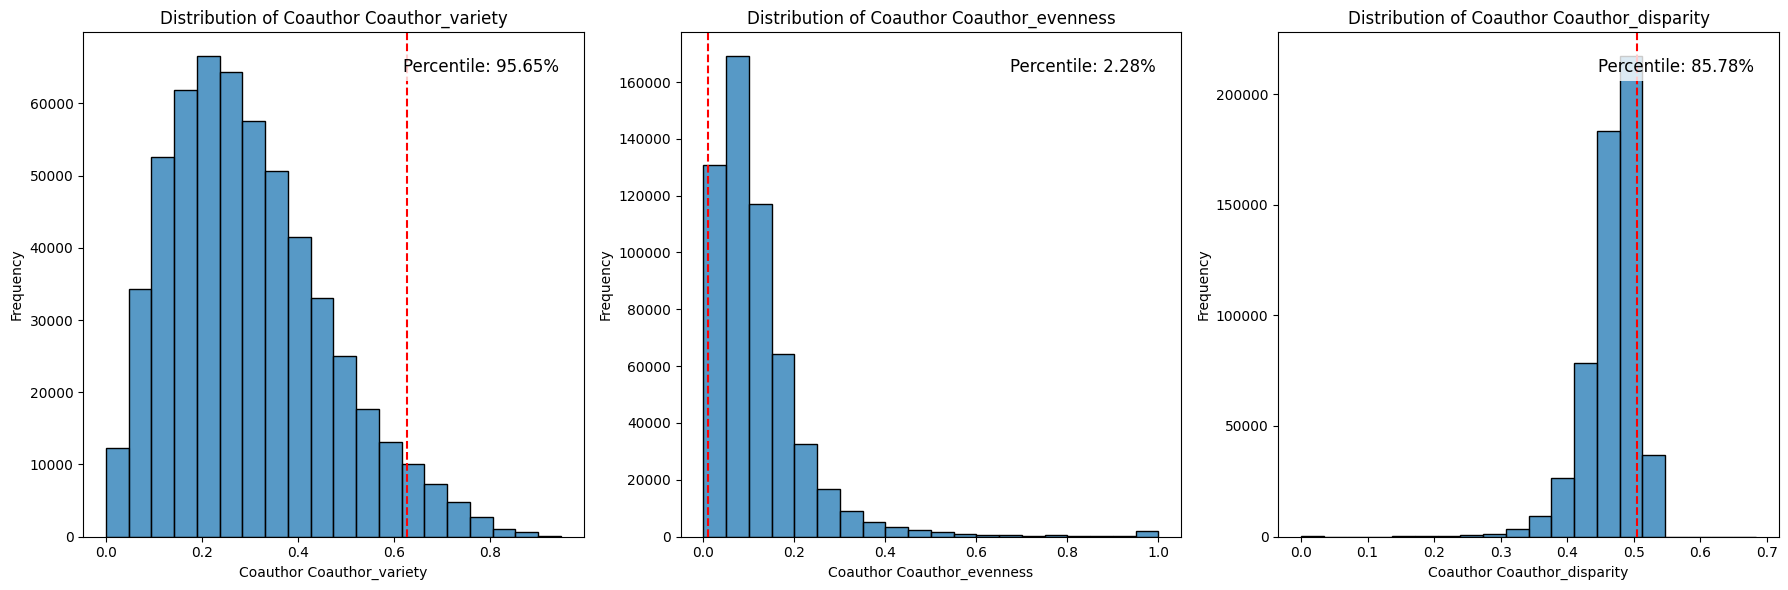

In [ ]:
# | code-fold: true
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_data = master_data[["id", "coauthor_variety", "coauthor_evenness", "coauthor_disparity"]].dropna()
reference_paper = plot_data.loc[plot_data["id"] == plot_data.loc[0]["id"]]

# Plot variety, evenness, and disparity
for i, metric in enumerate(["coauthor_variety", "coauthor_evenness", "coauthor_disparity"]):
    sns.histplot(plot_data[metric], bins=20, kde=False, ax=axes[i])
    axes[i].axvline(
        reference_paper[metric].values[0],
        color="red",
        linestyle="--",
        label="Reference Paper",
    )
    axes[i].set_title(f"Distribution of Coauthor {metric.capitalize()}")
    axes[i].set_xlabel(f"Coauthor {metric.capitalize()}")
    axes[i].set_ylabel("Frequency")
    percentile = percentileofscore(plot_data[metric], reference_paper[metric].values[0])
    axes[i].text(
        0.95, 0.95,
        f"Percentile: {percentile:.2f}%",
        transform=axes[i].transAxes,
        fontsize=18,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

Understanding the diversity of research teams is crucial, but why does it matter? One key hypothesis is that diversity in co-authorship and research topics might be linked to higher downstream impact, as measured by citation counts.

To explore this relationship, we use the dataset to run a regression analysis. The dependent variable is the year-normalised citation count (`cited_by_count_norm`), and the independent variables are the three diversity metrics: coauthor_variety, coauthor_evenness, and coauthor_disparity.

In [ ]:
# | code-fold: true

# Normalise citation counts by publication year
master_data["publication_year"] = master_data["publication_date"].str[:4].astype(int)
master_data["cited_by_count_norm"] = master_data[
    "cited_by_count"
] / master_data.groupby("publication_year")["cited_by_count"].transform("mean")

regression_data = master_data[
    [
        "cited_by_count_norm",
        "coauthor_variety",
        "coauthor_evenness",
        "coauthor_disparity",
    ]
].dropna()

scaler = StandardScaler()
X = regression_data[["coauthor_variety", "coauthor_evenness", "coauthor_disparity"]]
X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)
y = regression_data["cited_by_count_norm"]
model = sm.OLS(y, X_scaled).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     cited_by_count_norm   R-squared:                       0.018
Model:                             OLS   Adj. R-squared:                  0.018
Method:                  Least Squares   F-statistic:                     3338.
Date:                 Thu, 19 Dec 2024   Prob (F-statistic):               0.00
Time:                         21:35:45   Log-Likelihood:            -1.5243e+06
No. Observations:               557160   AIC:                         3.049e+06
Df Residuals:                   557156   BIC:                         3.049e+06
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0110      0.005    202.20

In this example without controls or fixed effects, and with particularly poor fit, we see that coauthor variety positively correlates with citation impact. Conversely, both evenness and disparity show slight negative associations, suggesting that balance and extreme field dissimilarity may not always enhance downstream influence. 